Question 4.1

In [1]:
x = [1,2,3,10] 
y = [10, 20, 30, 40]

Sum1 = [] # empty list that will be the sum of the two lists element-wise

for i in zip(x,y):
    Sum1.append(sum(i)) # adds the elements with the same index in the two lists

print(f"The first method: {Sum1}")

# the one-liner code:

Sum2 = []

#[Sum2.append(sum(i)) for i in zip(x,y)]
Sum2 = [sum(i) for i in zip(x,y)]

print(f"The second method: {Sum2}")

# the code using map():

def add(a,b):
    '''
    The function adds two numbers.
    Params: a,b (int/float/complex)
    Return: a+b (int/float/complex)
    '''
    return a+b

Sum3 = list(map(add,x,y))

print(f"The third method: {Sum3}")


The first method: [11, 22, 33, 50]
The second method: [11, 22, 33, 50]
The third method: [11, 22, 33, 50]


Question 4.3:

In [2]:
import numpy as np
user = input("Make your first move: type R for rock, P for paper and S for scissors (To end game, type:'Stop'):")

code = np.array(['R', 'P', 'S'])

while user != 'Stop':
    indx = np.random.randint(0, len(code))
    turn = code[indx]
    if user == 'R' or 'P' or 'S' or 'Stop':
        print("I played:", turn)
        if user == turn:
            print("It's a tie!")
        if user == 'R':
            if turn == 'P':
                print("I won!")
            if turn == 'S':
                print("You won!")
        if user == 'P':
            if turn == 'S':
                print("I won!")
            if turn == 'R':
                print("You won!")
        if user == 'S':
            if turn == 'R':
                print("I won!")
            if turn == 'P':
                print("You won!")
        user = input("Make your first move: type R for rock, P for paper and S for scissors:")

    else:
        user = input("Make your first move: type R for rock, P for paper and S for scissors:")
        

Make your first move: type R for rock, P for paper and S for scissors (To end game, type:'Stop'): Stop


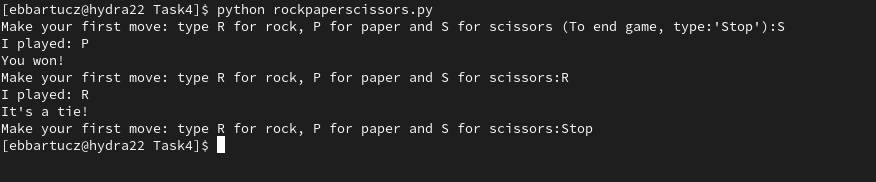

Question 4.4:

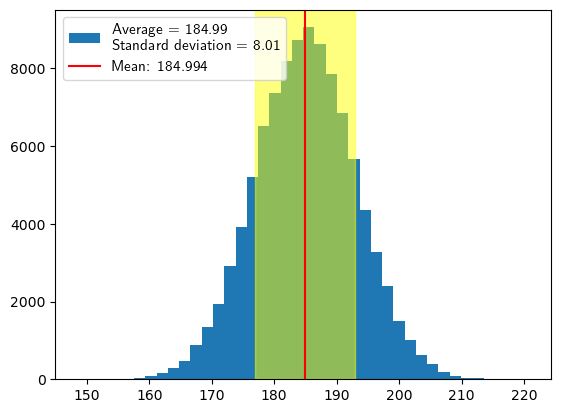

Please indicate the desired height h= 190


The chance of the data points being smaller than h: 0.7339758617378864
The chance of the data points being inside one sigma: 0.6826894921370852


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

lengths = np.random.normal(185.0,8.0,100000)

mean = np.mean(lengths) # their values are close to the inputed parameters
stdv = np.std(lengths)

plt.hist(lengths, bins=40, label = f"Average = {mean:.2f} "+"\n"+ f"Standard deviation = {stdv:.2f}")
plt.rc('text', usetex = True)
plt.axvline(mean, color='red', label=f'Mean: {mean:.3f}')
plt.axvspan((mean-stdv),(mean+stdv), color = 'yellow', alpha = 0.5)
plt.legend(fontsize = 11)
plt.show()

h = input("Please indicate the desired height h=")
print("The chance of the data points being smaller than h:",scipy.stats.norm.cdf(float(h),mean,stdv))

#function(desired value, mean, std) -> what percentage of data points is smaller (int(f)a-b = F(b)-F(a))
print("The chance of the data points being inside one sigma:",scipy.stats.norm.cdf((mean+stdv),mean,stdv)-scipy.stats.norm.cdf((mean-stdv),mean,stdv))

Question 4.6:

In [4]:
import numpy as np

def montecarlo(x,y,a,b,n):
    '''
    The function calculates the integral of a given function.
    Params: x (np.array) elements in the domain of the function
            y (str) the function that needs to be integrated
            a (float) the lower bound
            b (float) the upper bound
            n (int) the number of elements in x
    Return: integral (float): the integral obtained via the Monte Carlo method
    '''
    f = eval(y)
    integral = (b-a)/n*np.sum(f)
    return integral
    
a = float(input("Please input the lower bound:"))
b = float(input("Please input the upper bound:"))
n = 100000
x = np.random.uniform(a,b,100000)
y = str(input("Please input the function you wish to integrate:"))

print(montecarlo(x,y,a,b,n))
# control case:
# f(x) = x, a = 0, b = 1


Please input the lower bound: 0
Please input the upper bound: 1
Please input the function you wish to integrate: x


0.5003976969261074


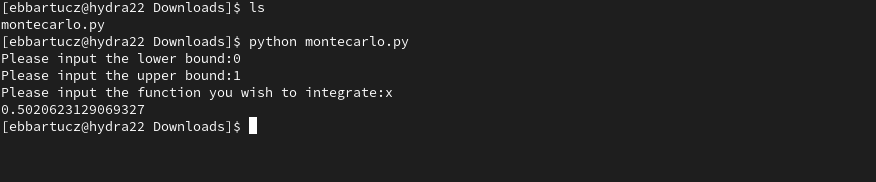

Question 4.12:

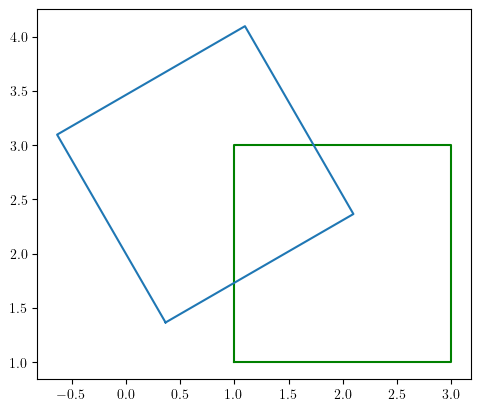

In [94]:
from math import *
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1,3,3,1,1])
y = np.array([1,1,3,3,1])

theta = radians(30)
rotor = cos(theta) + sin(theta)*1j

rot = rotor*(x+y*1j)
plt.gca().set_aspect('equal')
plt.plot(x,y, color = 'green')
plt.plot(rot.real,rot.imag)
plt.show()

Question 4.14:

In [61]:
def funcfilter(func,seq):
    '''
    The function filters all negative numbers and zero in the array.
    Params: func (function) the function applied to the filtered array
            seq (list,set,tuple,array) the array it filters
    Return: the filtered array    
    '''
    seq = np.asarray(seq)
    seq = seq[seq>0]
    return func(seq)

sq = 100
result = funcfilter(np.log10, sq)
print("Result log10:", result)
#test values: np.log10, np.array([-100, -10, 0, 10, 100])


Result log10: [2.]


Question 4.16:

In [83]:
from astropy.cosmology import Planck18
import scipy
from scipy import integrate
from math import sqrt

H0 = Planck18.H0.value #km/s/Mpc
Om0 = Planck18.Om0
Ode0 = Planck18.Ode0

z = float(input("Please input the redshift:"))
a = 0
b = z

def H(z):
    H = H0*sqrt(Om0*(1+z)**3+Ode0)
    return H
def I(z):
    I = 1/((1+z)*H(z))
    return I

tL,dtL = scipy.integrate.quad(I,a,b)

t = ((3.086*10**16)*10**6/(1000*3600*24*365.25*10**9))*tL

print(f"The lookback time in Gyr:{t:.2f}")

Please input the redshift:2
The lookback time in Gyr:10.53


Question 4.21:

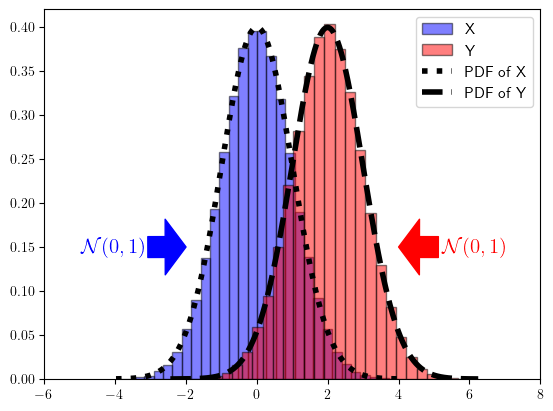

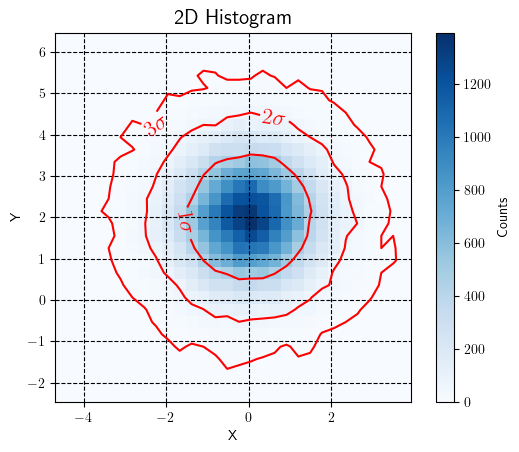

In [96]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots, show

X = np.random.normal(0.0,1.0,100000)
Y = np.random.normal(2.0,1.0,100000)

#calc pdf

pdfx = norm.pdf(np.sort(X),np.mean(X),np.std(X))
pdfy = norm.pdf(np.sort(Y),np.mean(Y),np.std(Y))

# first diagram

plt.hist(X, bins = 30, color = 'blue', alpha = 0.5, label = 'X', density = True, ec = 'k')
plt.hist(Y, bins = 30, color = 'red', alpha = 0.5, label = 'Y', density = True, ec = 'k')
plt.xlim(-6,8)
plt.ylim(0,0.42)
plt.plot(np.sort(X),pdfx, color = 'black', label = 'PDF of X', linestyle = ':', linewidth = 4)
plt.plot(np.sort(Y),pdfy, color = 'black', label = 'PDF of Y', linestyle = '--', linewidth = 4)

#creating arrows and annotated text

plt.annotate(r'$\mathcal{N}(0,1)$', fontsize = 15,xy = (-2,0.15),color = 'blue', xytext = (-5,0.144), arrowprops = {'width':15,'headwidth':40,'headlength':15,'color':'blue'})
plt.annotate(r'$\mathcal{N}(0,1)$',fontsize = 15, xy = (4,0.15),color = 'red', xytext = (5.2,0.144), arrowprops = {'width':15,'headwidth':40,'headlength':15,'color':'red'})
plt.legend(fontsize = 11)
plt.show()

# second diagram

X = np.random.normal(0.0,1.0,100000)
Y = np.random.normal(2.0,1.0,100000)

# extracting count and edges of each bin from the 2D histogram (and plotting it): 

H,xedges,yedges,image = plt.hist2d(X,Y,bins=30,cmap = "Blues")
plt.colorbar(label="Counts")

H = H.T # transposing count matrix to have cartesian coordinates

# calculating the center of each bin

x = (xedges[:-1] + xedges[1:])/2 
y = (yedges[:-1] + yedges[1:])/2
xc,yc = np.meshgrid(x,y)

Hflat = H.flatten() # putting bins side by side
Hsorted = np.sort(Hflat)[::-1] # sort bins from highest count to lowest
cdf = np.cumsum(Hsorted) # calculate cumulated probability distribution from left to right
cdf /= cdf[-1] # norm the cumulated probability function with the last entry

levels = []

for i in [0.68,0.95,0.997]:
    levels.append(Hsorted[np.searchsorted(cdf,i)]) # find values corresponding to the probabilities in the sorted cdf and add it to levels

labels = ['$3\sigma$','$2\sigma$','$1\sigma$']
levels = levels[::-1] # levels have to be increasing

contour = plt.contour(xc,yc,H,levels = levels, colors = 'red') #defining and plotting contours
plt.rc('text', usetex = True)
plt.clabel(contour, inline = 1, fontsize = 16, fmt = {levels[i]:labels[i] for i in range (len(levels))}) # adding labels to contours
plt.xlabel("X")
plt.ylabel("Y")
plt.gca().set_aspect('equal') # making it not ellipsoidal
plt.title("2D Histogram", fontsize = 15)
plt.grid(linestyle = '--', color = 'black')
plt.show()